In [46]:
import pandas as pd
import os
from utils.ml_utils_v2 import EmissionsPredictionPipeline, XGBMultiOutputPipeline
from utils.eda_utils import EDAUtils, DataCleaningUtils
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

In [47]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")

In [49]:
RUN_ID = "1770424763"
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, f"training_data_w_suffix_{RUN_ID}.csv") #NOTE: update filename as needed
training_df = pd.read_csv(TRAINING_DATA_PATH)
training_df = training_df.drop(columns=["primary_id", "future_id"])
training_df.head()

,group_28_L_Carrying Capacity Scalar,group_67_X_elasticity_trde_mtkm_to_gdp_freight,group_26_L_Livestock Manure Management Fraction,group_29_L_Fraction Eating Red Meat,group_37_L_Transportation Demand Scalar,group_4_L_Crop Yield Factor,group_45_L_Freight Transportation Mode Share,group_68_X_elasticity_trde_pkm_to_gdppc,group_41_L_Transportation Mode Fuel Fraction,group_30_L_Industrial :math:\text{CO}_2 Capture Prevalence,...,2033_2037_mean_emission,2066_2070_mean_emission,2025_2035_mean_benefits,2025_2070_mean_benefits,2025_2035_mean_costs,2025_2070_mean_costs,2025_2035_cumulative_costs_rel_to_gdp,2025_2070_cumulative_costs_rel_to_gdp,2025_2035_max_costs_rel_to_gdp,2025_2070_max_costs_rel_to_gdp
0,0.807477,-1.0,0.131542,0.442982,0.563116,0.224786,0.920123,-1.0,0.965043,0.347242,...,155.943011,162.178247,2.934405,19.269972,0.448135,0.834822,0.021524,0.081056,0.003210,0.003797
1,0.293751,-1.0,0.487078,0.121257,0.846307,0.131869,0.240794,-1.0,0.793528,0.952303,...,148.164485,165.491078,3.086639,20.875301,0.450949,1.094102,0.021664,0.096277,0.003223,0.004213
2,0.782886,-1.0,0.938930,0.202128,0.334866,0.362636,0.792576,-1.0,0.947752,0.234018,...,149.924342,167.532309,3.027576,20.253282,0.455116,0.946547,0.021841,0.087648,0.003264,0.003950
3,0.926488,-1.0,0.439874,0.205361,0.792520,0.112839,0.216897,-1.0,0.766077,0.837764,...,155.716764,171.095935,3.027648,20.315354,0.473642,1.031214,0.022664,0.093661,0.003431,0.004125
4,0.149876,-1.0,0.719120,0.460605,0.363667,0.207972,0.887910,-1.0,0.372594,0.322780,...,142.184124,152.521376,3.009067,20.038498,0.420872,0.882343,0.020320,0.082283,0.002963,0.003828


In [15]:
# print(sorted([col for col in training_df.columns if "_L_" in col]))

## EDA

In [16]:
edau = EDAUtils()

In [17]:
target_col = [
    col
    for col in training_df.columns
    if not col.startswith(("group_")) and col not in ["future_id", "primary_id"]
]
target_col

['emission_total_sum',
 '2033_2037_mean_emission',
 '2066_2070_mean_emission',
 '2025_2035_mean_benefits',
 '2025_2070_mean_benefits',
 '2025_2035_mean_costs',
 '2025_2070_mean_costs',
 '2025_2035_cumulative_costs_rel_to_gdp',
 '2025_2070_cumulative_costs_rel_to_gdp',
 '2025_2035_max_costs_rel_to_gdp',
 '2025_2070_max_costs_rel_to_gdp']

In [18]:
lhs_group_cols = [col for col in training_df.columns if col.startswith("group_")]
lhs_group_cols

['group_28_L_Carrying Capacity Scalar',
 'group_67_X_elasticity_trde_mtkm_to_gdp_freight',
 'group_26_L_Livestock Manure Management Fraction ',
 'group_29_L_Fraction Eating Red Meat',
 'group_37_L_Transportation Demand Scalar',
 'group_4_L_Crop Yield Factor',
 'group_45_L_Freight Transportation Mode Share',
 'group_68_X_elasticity_trde_pkm_to_gdppc',
 'group_41_L_Transportation Mode Fuel Fraction ',
 'group_30_L_Industrial :math:\\text{CO}_2 Capture Prevalence',
 'group_17_L_:math:\\text{N}_2\\text{O} ',
 'group_25_L_Livestock Manure Management Fraction ',
 'group_52_L_Treatment Fraction ',
 'group_58_L_Fraction of Non-Recycled Solid Waste ',
 'group_59_L_Fraction of Waste Recycled',
 'group_38_L_Electrical Vehicle Efficiency',
 'group_35_L_Liming Demand Scalar',
 'group_55_L_Fraction of Landfill Gas Recovered at Landfills',
 'group_66_X_elasticity_scoe_enerdem_per',
 'group_33_L_SCOE Efficiency Factor for Heat Energy from Solid Biomass',
 'group_61_X_cost_enfu_fuel',
 'group_2_L_Fract

In [21]:
training_df[target_col].describe()

,emission_total_sum,2033_2037_mean_emission,2066_2070_mean_emission,2025_2035_mean_benefits,2025_2070_mean_benefits,2025_2035_mean_costs,2025_2070_mean_costs,2025_2035_cumulative_costs_rel_to_gdp,2025_2070_cumulative_costs_rel_to_gdp,2025_2035_max_costs_rel_to_gdp,2025_2070_max_costs_rel_to_gdp
count,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000
mean,6614.627110,140.633123,131.766527,3.085754,20.860816,0.453183,1.064820,0.023530,0.105497,0.003612,0.004516
std,546.750170,7.990946,22.961831,0.123867,1.666178,0.022903,0.215790,0.002378,0.019270,0.000497,0.000670
min,4879.944208,114.324085,62.406392,2.774586,16.474692,0.386365,0.564739,0.019763,0.071386,0.002848,0.003360
25%,6259.099298,135.583507,115.711886,2.987476,19.637186,0.436997,0.892438,0.021799,0.091138,0.003256,0.004034
50%,6643.695407,141.613405,131.698188,3.083970,20.776785,0.453193,1.053841,0.022860,0.103460,0.003462,0.004360
75%,7003.146542,146.340294,147.924648,3.184884,22.116020,0.469480,1.233063,0.024796,0.115858,0.003865,0.004848
max,8291.683846,158.835610,205.918255,3.335583,25.027960,0.516390,1.618471,0.031774,0.182539,0.005367,0.007137


In [22]:
print("Shape before dropping zero columns:", training_df.shape)
# Drop columns full of zeros
cols_to_drop = []
for col in training_df.columns:
    if (training_df[col] == 0).all():
        cols_to_drop.append(col)
training_df = training_df.drop(columns=cols_to_drop)
print("Shape after dropping zero columns:", training_df.shape)

Shape before dropping zero columns: (1933, 79)
Shape after dropping zero columns: (1933, 79)


In [23]:
# Check for NaN and infinite values in the training data
for col in training_df.columns:
    nans = training_df[col].isna().sum()
    neg_infs = (training_df[col] == -np.inf).sum()
    pos_infs = (training_df[col] == np.inf).sum()
    if nans > 0 or neg_infs > 0 or pos_infs > 0:
        print(f"WARNING: Column '{col}' has {nans} NaNs, {neg_infs} -inf, {pos_infs} inf values.")

In [24]:
# Recompute target_col after dropping zero columns
target_col = [
    col
    for col in training_df.columns
    if not col.startswith(("group_")) and col not in ["future_id", "primary_id"]
]
target_col

['emission_total_sum',
 '2033_2037_mean_emission',
 '2066_2070_mean_emission',
 '2025_2035_mean_benefits',
 '2025_2070_mean_benefits',
 '2025_2035_mean_costs',
 '2025_2070_mean_costs',
 '2025_2035_cumulative_costs_rel_to_gdp',
 '2025_2070_cumulative_costs_rel_to_gdp',
 '2025_2035_max_costs_rel_to_gdp',
 '2025_2070_max_costs_rel_to_gdp']

In [25]:
training_df[target_col].describe()

,emission_total_sum,2033_2037_mean_emission,2066_2070_mean_emission,2025_2035_mean_benefits,2025_2070_mean_benefits,2025_2035_mean_costs,2025_2070_mean_costs,2025_2035_cumulative_costs_rel_to_gdp,2025_2070_cumulative_costs_rel_to_gdp,2025_2035_max_costs_rel_to_gdp,2025_2070_max_costs_rel_to_gdp
count,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000
mean,6614.627110,140.633123,131.766527,3.085754,20.860816,0.453183,1.064820,0.023530,0.105497,0.003612,0.004516
std,546.750170,7.990946,22.961831,0.123867,1.666178,0.022903,0.215790,0.002378,0.019270,0.000497,0.000670
min,4879.944208,114.324085,62.406392,2.774586,16.474692,0.386365,0.564739,0.019763,0.071386,0.002848,0.003360
25%,6259.099298,135.583507,115.711886,2.987476,19.637186,0.436997,0.892438,0.021799,0.091138,0.003256,0.004034
50%,6643.695407,141.613405,131.698188,3.083970,20.776785,0.453193,1.053841,0.022860,0.103460,0.003462,0.004360
75%,7003.146542,146.340294,147.924648,3.184884,22.116020,0.469480,1.233063,0.024796,0.115858,0.003865,0.004848
max,8291.683846,158.835610,205.918255,3.335583,25.027960,0.516390,1.618471,0.031774,0.182539,0.005367,0.007137


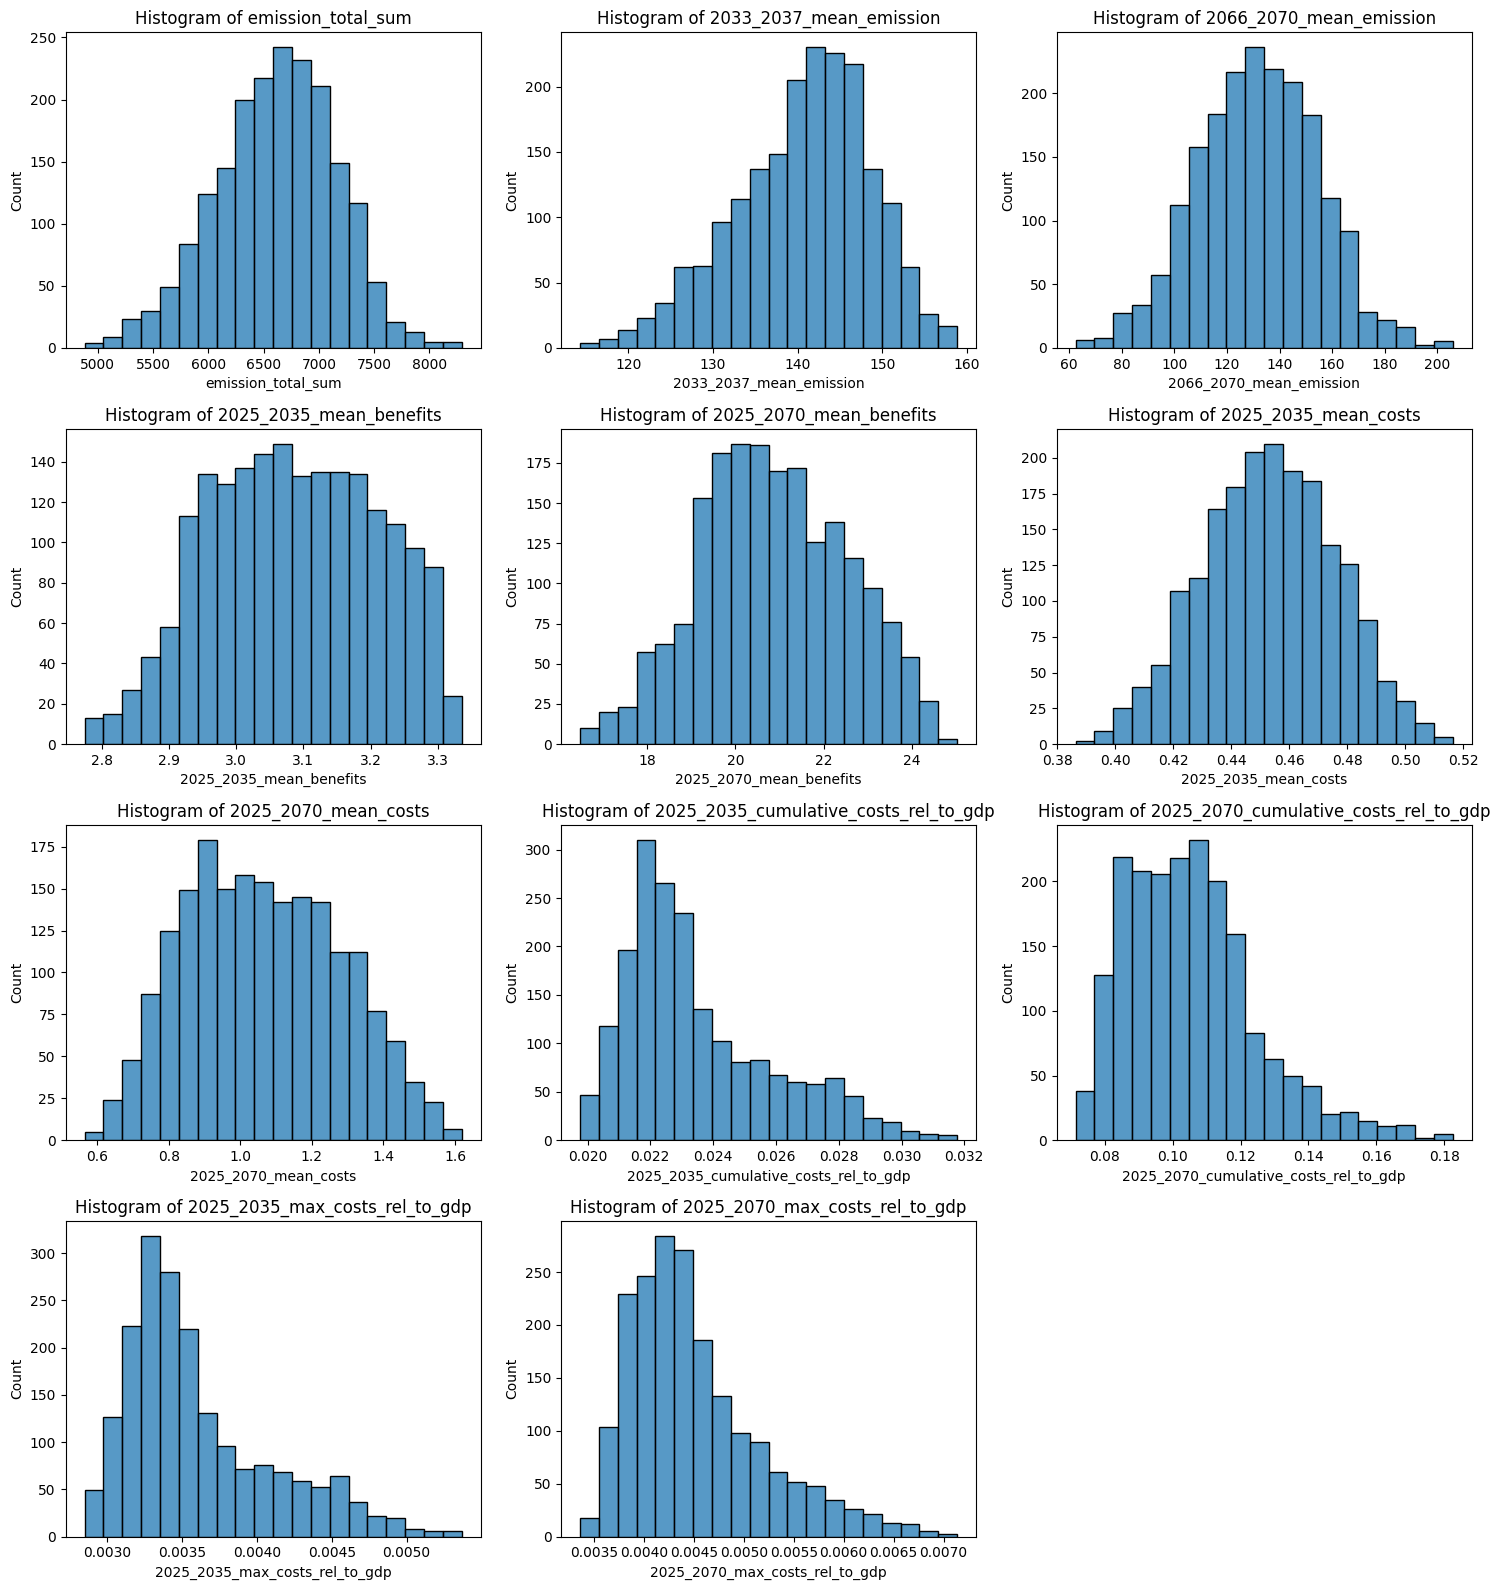

In [26]:
edau.plot_multiple_histograms(training_df, target_col, bins=20, kde=False)
                              

In [27]:

for col in target_col:
    edau.get_target_var_corr(training_df, col, exclude_cols=target_col)


Correlation with target variable 'emission_total_sum' (threshold: 0.1):
--------------------------------------------------
group_34_L_SCOE Fraction Heat Energy Demand  : 0.4181
group_60_X_exports             : 0.4120
group_66_X_elasticity_scoe_enerdem_per : 0.4100
group_64_X_elasticity_ippu_product_use : 0.4093
group_63_X_elasticity_ippu     : 0.4028
group_61_X_cost_enfu_fuel      : 0.4026
group_67_X_elasticity_trde_mtkm_to_gdp_freight : 0.4009
group_68_X_elasticity_trde_pkm_to_gdppc : 0.3961
group_65_X_population_gnrl     : 0.3710
group_62_X_gdp_mmm_usd         : 0.2850
group_27_L_:math:\text{CH}_4 Enteric Fermentation Emission Factor : 0.2677
group_19_L_Unadjusted Land Use Transition Probability : 0.2675
group_31_L_SCOE Heat Energy Demand Scalar : 0.1832
group_29_L_Fraction Eating Red Meat : 0.1826
group_58_L_Fraction of Non-Recycled Solid Waste  : 0.1339


Correlation with target variable '2033_2037_mean_emission' (threshold: 0.1):
--------------------------------------------------

In [28]:
# Outlier inspection
outliers = edau.find_outlier_columns(training_df, method="iqr", factor=1.5)
print("Outlier percentages:", outliers)
outliers = edau.find_outlier_columns(training_df, method="zscore", z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'emission_total_sum': 0.67, '2033_2037_mean_emission': 0.83, '2066_2070_mean_emission': 0.47, '2025_2035_mean_costs': 0.05, '2025_2035_cumulative_costs_rel_to_gdp': 2.17, '2025_2070_cumulative_costs_rel_to_gdp': 2.74, '2025_2035_max_costs_rel_to_gdp': 2.74, '2025_2070_max_costs_rel_to_gdp': 3.47}
Outlier percentages: {'emission_total_sum': 0.21, '2033_2037_mean_emission': 0.21, '2066_2070_mean_emission': 0.36, '2025_2035_cumulative_costs_rel_to_gdp': 0.62, '2025_2070_cumulative_costs_rel_to_gdp': 1.35, '2025_2035_max_costs_rel_to_gdp': 0.62, '2025_2070_max_costs_rel_to_gdp': 1.09}


## Data Cleaning

In [29]:
dcu = DataCleaningUtils()

In [30]:
training_df.shape

(1933, 79)

In [31]:
# # Check those -inf values in technical_cost
# technical_cost_neg_inf = training_df[training_df["technical_cost"] == -np.inf]
# technical_cost_neg_inf

In [32]:
# # filter out -inf values in technical_cost
# training_df = training_df[training_df["technical_cost"] != -np.inf]
# training_df.shape

In [33]:
training_df_cleaned = dcu.remove_outliers(training_df, method="zscore", z_thresh=3.0)
print("Shape before removing outliers:", training_df.shape)
print("Shape after removing outliers:", training_df_cleaned.shape)

Shape before removing outliers: (1933, 79)
Shape after removing outliers: (1890, 79)


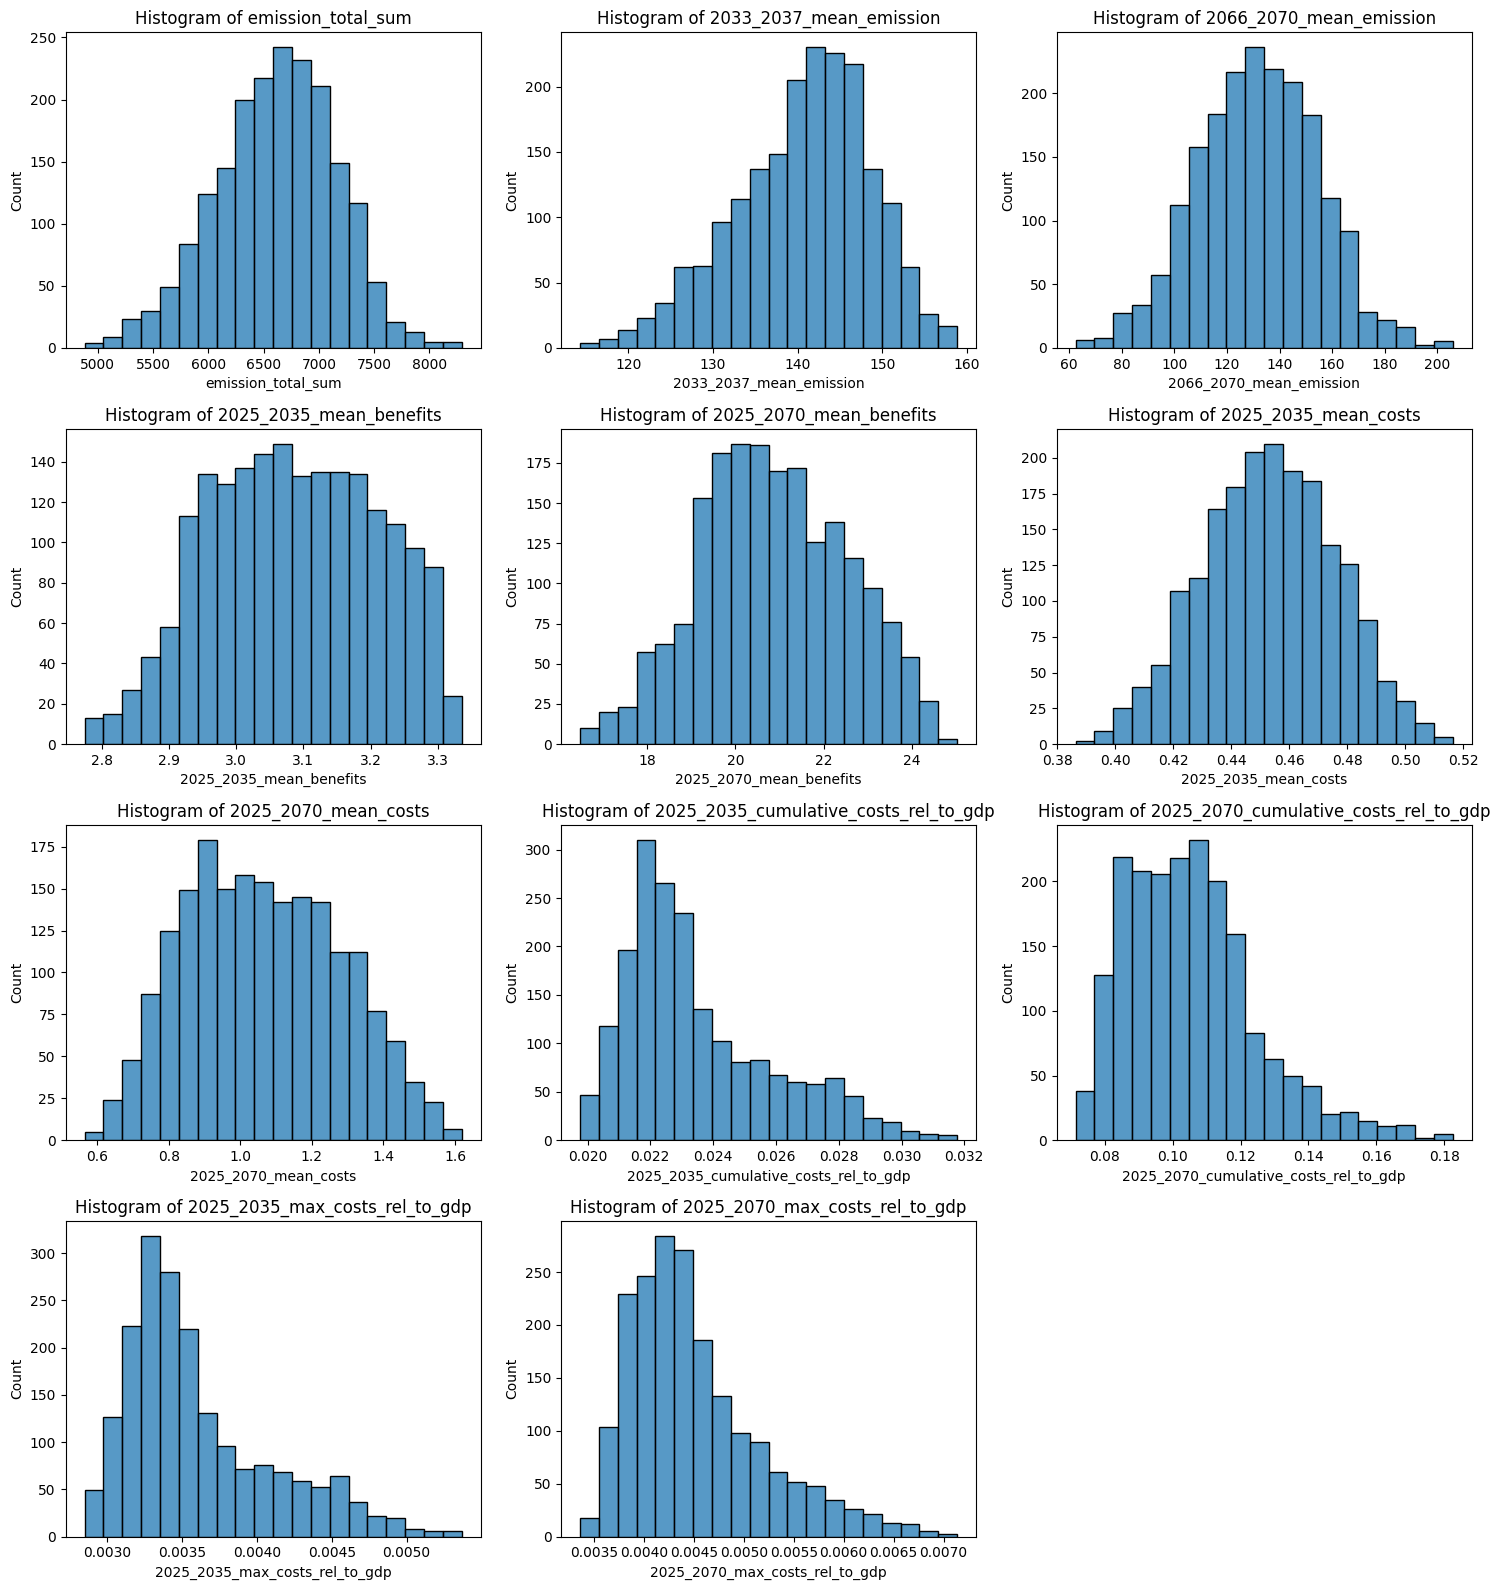

In [34]:
edau.plot_multiple_histograms(training_df, target_col, bins=20, kde=False)

In [35]:
outliers = edau.find_outlier_columns(training_df_cleaned, method="zscore", z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'2033_2037_mean_emission': 0.21, '2025_2035_cumulative_costs_rel_to_gdp': 0.21, '2025_2070_cumulative_costs_rel_to_gdp': 0.32, '2025_2035_max_costs_rel_to_gdp': 0.26, '2025_2070_max_costs_rel_to_gdp': 0.69}


In [36]:
for col in target_col:
    edau.get_target_var_corr(training_df_cleaned, col, exclude_cols=target_col)


Correlation with target variable 'emission_total_sum' (threshold: 0.1):
--------------------------------------------------
group_34_L_SCOE Fraction Heat Energy Demand  : 0.4258
group_60_X_exports             : 0.4086
group_64_X_elasticity_ippu_product_use : 0.4051
group_66_X_elasticity_scoe_enerdem_per : 0.4044
group_61_X_cost_enfu_fuel      : 0.3975
group_67_X_elasticity_trde_mtkm_to_gdp_freight : 0.3935
group_68_X_elasticity_trde_pkm_to_gdppc : 0.3921
group_63_X_elasticity_ippu     : 0.3915
group_65_X_population_gnrl     : 0.3666
group_62_X_gdp_mmm_usd         : 0.2895
group_19_L_Unadjusted Land Use Transition Probability : 0.2642
group_27_L_:math:\text{CH}_4 Enteric Fermentation Emission Factor : 0.2633
group_31_L_SCOE Heat Energy Demand Scalar : 0.1905
group_29_L_Fraction Eating Red Meat : 0.1768
group_58_L_Fraction of Non-Recycled Solid Waste  : 0.1296


Correlation with target variable '2033_2037_mean_emission' (threshold: 0.1):
--------------------------------------------------

In [37]:
# edau.plot_multiple_histograms(training_df_cleaned, training_df_cleaned.drop(columns=["emission_total"]).columns.tolist(), bins=30, kde=False)

In [38]:
# training_df_cleaned[target_cols].describe()

In [39]:
# sns.pairplot(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

In [40]:
# edau.plot_correlation_matrix(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

## ML


=== XGB (TEST results) ===
emission_total_sum             → MAE: 145.6348 | RMSE: 188.9391 | R²: 0.8802 | SMAPE: 2.2%
2033_2037_mean_emission        → MAE: 1.5277 | RMSE: 1.8965 | R²: 0.9422 | SMAPE: 1.1%
2066_2070_mean_emission        → MAE: 6.9081 | RMSE: 8.6509 | R²: 0.8591 | SMAPE: 5.4%
2025_2035_mean_benefits        → MAE: 0.0068 | RMSE: 0.0119 | R²: 0.9905 | SMAPE: 0.2%
2025_2070_mean_benefits        → MAE: 0.1277 | RMSE: 0.2322 | R²: 0.9808 | SMAPE: 0.6%
2025_2035_mean_costs           → MAE: 0.0031 | RMSE: 0.0041 | R²: 0.9692 | SMAPE: 0.7%
2025_2070_mean_costs           → MAE: 0.0245 | RMSE: 0.0315 | R²: 0.9791 | SMAPE: 2.3%
2025_2035_cumulative_costs_rel_to_gdp → MAE: 0.0002 | RMSE: 0.0003 | R²: 0.9853 | SMAPE: 0.8%
2025_2070_cumulative_costs_rel_to_gdp → MAE: 0.0022 | RMSE: 0.0033 | R²: 0.9652 | SMAPE: 2.1%
2025_2035_max_costs_rel_to_gdp → MAE: 0.0001 | RMSE: 0.0001 | R²: 0.9481 | SMAPE: 2.2%
2025_2070_max_costs_rel_to_gdp → MAE: 0.0001 | RMSE: 0.0001 | R²: 0.9578 | SMAPE: 2.

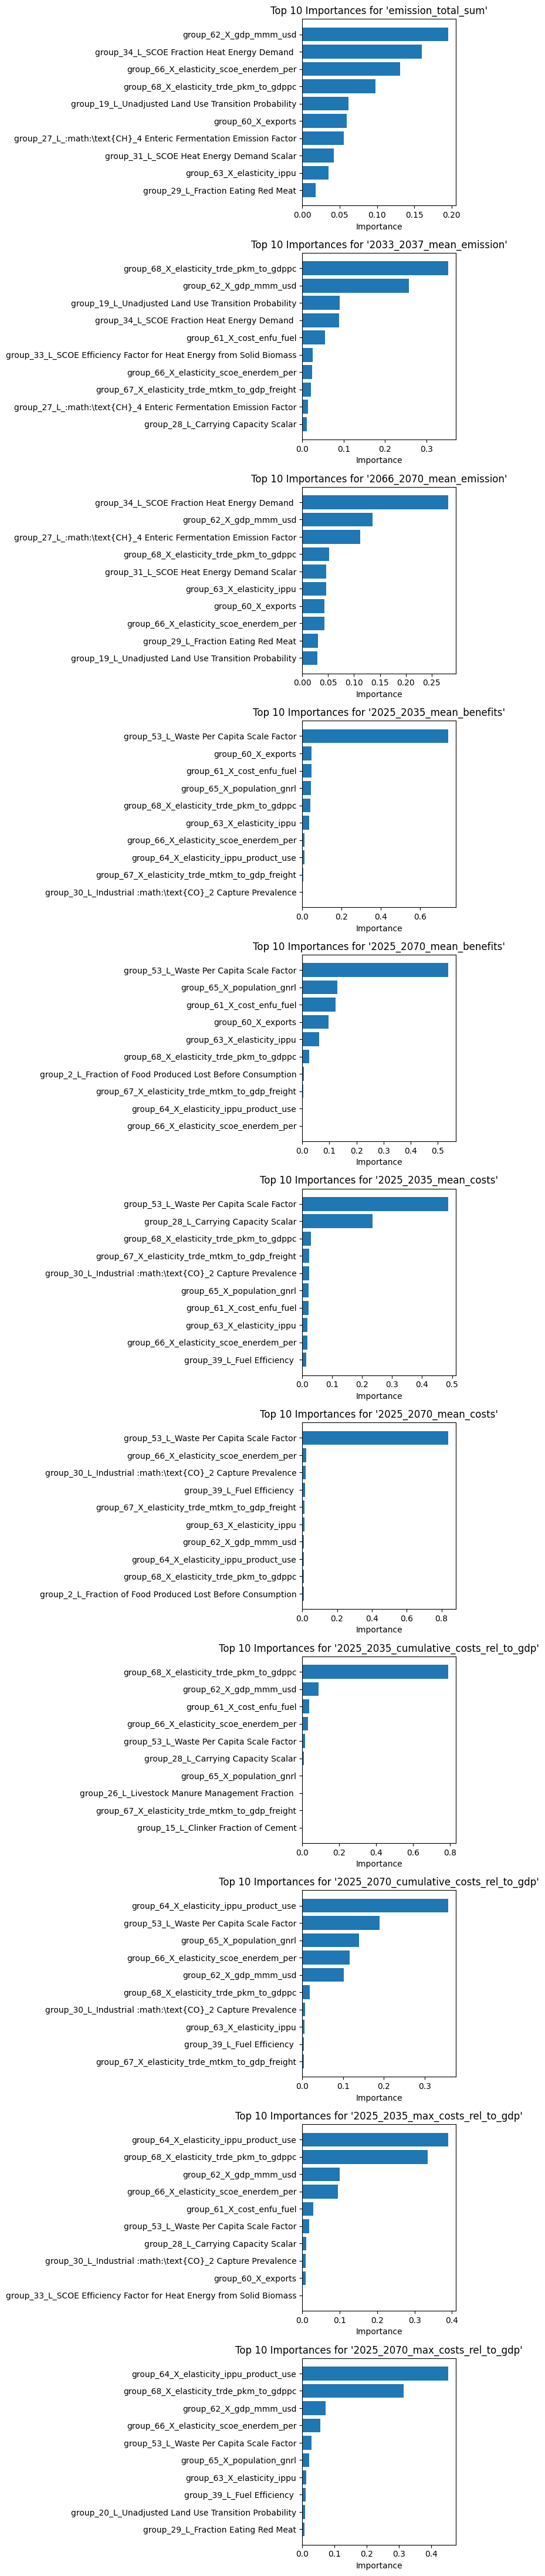

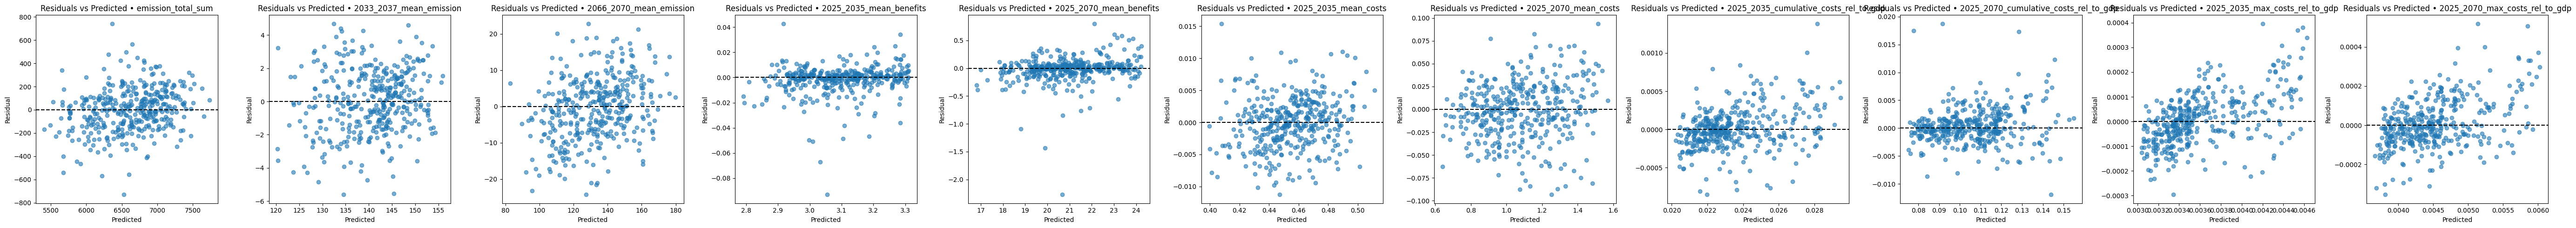

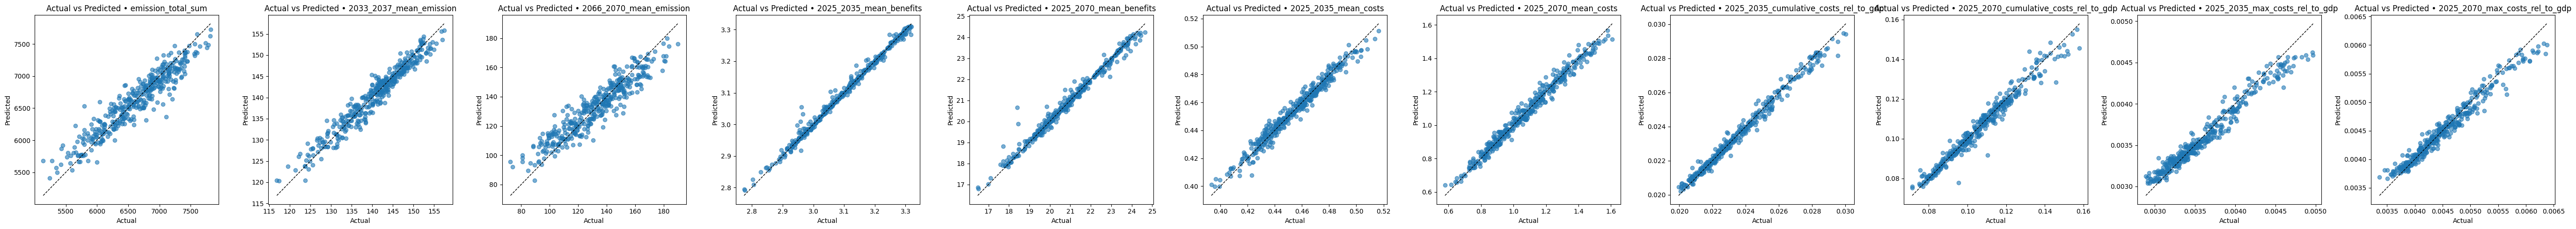

In [41]:
mulp = XGBMultiOutputPipeline(df=training_df_cleaned, targets=target_col)
mulp.run(tune=False, log_transform=False, plot_figures=True)

## Save the trained and tuned model and use it to predict new data

In [42]:
training_df_cleaned.head()

,group_28_L_Carrying Capacity Scalar,group_67_X_elasticity_trde_mtkm_to_gdp_freight,group_26_L_Livestock Manure Management Fraction,group_29_L_Fraction Eating Red Meat,group_37_L_Transportation Demand Scalar,group_4_L_Crop Yield Factor,group_45_L_Freight Transportation Mode Share,group_68_X_elasticity_trde_pkm_to_gdppc,group_41_L_Transportation Mode Fuel Fraction,group_30_L_Industrial :math:\text{CO}_2 Capture Prevalence,...,2033_2037_mean_emission,2066_2070_mean_emission,2025_2035_mean_benefits,2025_2070_mean_benefits,2025_2035_mean_costs,2025_2070_mean_costs,2025_2035_cumulative_costs_rel_to_gdp,2025_2070_cumulative_costs_rel_to_gdp,2025_2035_max_costs_rel_to_gdp,2025_2070_max_costs_rel_to_gdp
0,0.807477,-1.0,0.131542,0.442982,0.563116,0.224786,0.920123,-1.0,0.965043,0.347242,...,155.943011,162.178247,2.934405,19.269972,0.448135,0.834822,0.021524,0.081056,0.003210,0.003797
1,0.293751,-1.0,0.487078,0.121257,0.846307,0.131869,0.240794,-1.0,0.793528,0.952303,...,148.164485,165.491078,3.086639,20.875301,0.450949,1.094102,0.021664,0.096277,0.003223,0.004213
2,0.782886,-1.0,0.938930,0.202128,0.334866,0.362636,0.792576,-1.0,0.947752,0.234018,...,149.924342,167.532309,3.027576,20.253282,0.455116,0.946547,0.021841,0.087648,0.003264,0.003950
3,0.926488,-1.0,0.439874,0.205361,0.792520,0.112839,0.216897,-1.0,0.766077,0.837764,...,155.716764,171.095935,3.027648,20.315354,0.473642,1.031214,0.022664,0.093661,0.003431,0.004125
4,0.149876,-1.0,0.719120,0.460605,0.363667,0.207972,0.887910,-1.0,0.372594,0.322780,...,142.184124,152.521376,3.009067,20.038498,0.420872,0.882343,0.020320,0.082283,0.002963,0.003828


In [43]:
# Get a single row from training_df_cleaned for prediction
single_row = training_df_cleaned.iloc[0].drop(columns="emission_total")
single_row = single_row.to_frame().T  # Convert to DataFrame
single_row

,group_28_L_Carrying Capacity Scalar,group_67_X_elasticity_trde_mtkm_to_gdp_freight,group_26_L_Livestock Manure Management Fraction,group_29_L_Fraction Eating Red Meat,group_37_L_Transportation Demand Scalar,group_4_L_Crop Yield Factor,group_45_L_Freight Transportation Mode Share,group_68_X_elasticity_trde_pkm_to_gdppc,group_41_L_Transportation Mode Fuel Fraction,group_30_L_Industrial :math:\text{CO}_2 Capture Prevalence,...,2033_2037_mean_emission,2066_2070_mean_emission,2025_2035_mean_benefits,2025_2070_mean_benefits,2025_2035_mean_costs,2025_2070_mean_costs,2025_2035_cumulative_costs_rel_to_gdp,2025_2070_cumulative_costs_rel_to_gdp,2025_2035_max_costs_rel_to_gdp,2025_2070_max_costs_rel_to_gdp
0,0.807477,-1.0,0.131542,0.442982,0.563116,0.224786,0.920123,-1.0,0.965043,0.347242,...,155.943011,162.178247,2.934405,19.269972,0.448135,0.834822,0.021524,0.081056,0.00321,0.003797


In [44]:
# Predict using the trained model
predictions = mulp.predict(single_row)
print("Predictions for single row:")
predictions

Predictions for single row:


,emission_total_sum,2033_2037_mean_emission,2066_2070_mean_emission,2025_2035_mean_benefits,2025_2070_mean_benefits,2025_2035_mean_costs,2025_2070_mean_costs,2025_2035_cumulative_costs_rel_to_gdp,2025_2070_cumulative_costs_rel_to_gdp,2025_2035_max_costs_rel_to_gdp,2025_2070_max_costs_rel_to_gdp
0,7431.232422,155.949707,162.342361,2.934349,19.267984,0.448377,0.835138,0.02161,0.080961,0.003303,0.003819


In [45]:
print("Original values:")
print(training_df_cleaned.iloc[0][target_col])

Original values:
emission_total_sum                       7431.303667
2033_2037_mean_emission                   155.943011
2066_2070_mean_emission                   162.178247
2025_2035_mean_benefits                     2.934405
2025_2070_mean_benefits                    19.269972
2025_2035_mean_costs                        0.448135
2025_2070_mean_costs                        0.834822
2025_2035_cumulative_costs_rel_to_gdp       0.021524
2025_2070_cumulative_costs_rel_to_gdp       0.081056
2025_2035_max_costs_rel_to_gdp              0.003210
2025_2070_max_costs_rel_to_gdp              0.003797
Name: 0, dtype: float64


In [50]:
# Save the trained model
xgb_pipeline = mulp.pipeline  # only one now
TRAINED_MODELS_DIR = os.path.join(SCRIPT_DIR_PATH, "trained_models")
model_file_name = f"xgb_pipeline_{RUN_ID}.pkl"
os.makedirs(TRAINED_MODELS_DIR, exist_ok=True)
overwrite_existing_model = True  # Set to True to overwrite existing model

MODEL_PATH = os.path.join(TRAINED_MODELS_DIR, model_file_name)
if os.path.exists(MODEL_PATH) and not overwrite_existing_model:
    print(f"Model {model_file_name} already exists at {MODEL_PATH}. Skipping save.")
else:
    print(f"Saving model to {MODEL_PATH} ...")
    joblib.dump(xgb_pipeline, MODEL_PATH)
    print("✅ Model saved successfully.")

Saving model to /Users/tony/Documents/sisepuede_modeling/ssp_uganda_data/metamodel/surrogate_model/trained_models/xgb_pipeline_1770424763.pkl ...
✅ Model saved successfully.


In [51]:
# Load the trained model and test predictions
xgb_pipeline_loaded = joblib.load(MODEL_PATH)

In [52]:
# Predict using the trained model
predictions = mulp.predict(single_row)
print("Predictions for single row:")
predictions

Predictions for single row:


,emission_total_sum,2033_2037_mean_emission,2066_2070_mean_emission,2025_2035_mean_benefits,2025_2070_mean_benefits,2025_2035_mean_costs,2025_2070_mean_costs,2025_2035_cumulative_costs_rel_to_gdp,2025_2070_cumulative_costs_rel_to_gdp,2025_2035_max_costs_rel_to_gdp,2025_2070_max_costs_rel_to_gdp
0,7431.232422,155.949707,162.342361,2.934349,19.267984,0.448377,0.835138,0.02161,0.080961,0.003303,0.003819


In [53]:
print("Original values:")
training_df_cleaned.iloc[0][target_col]

Original values:


emission_total_sum                       7431.303667
2033_2037_mean_emission                   155.943011
2066_2070_mean_emission                   162.178247
2025_2035_mean_benefits                     2.934405
2025_2070_mean_benefits                    19.269972
2025_2035_mean_costs                        0.448135
2025_2070_mean_costs                        0.834822
2025_2035_cumulative_costs_rel_to_gdp       0.021524
2025_2070_cumulative_costs_rel_to_gdp       0.081056
2025_2035_max_costs_rel_to_gdp              0.003210
2025_2070_max_costs_rel_to_gdp              0.003797
Name: 0, dtype: float64